# Summary figure containing constrained 90% confidence intervals for ∆lnLWP and ERFaci
* ∆lnLWP and ERFaci, using ALL of the constraints (PD LWP, da/dlwp, dNd)
* Compare to WCRP ranges


In [1]:
import pickle

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import tol_colors as tc
import multi_ppe_constraint_rev as mpc

from matplotlib.gridspec import GridSpec
from matplotlib.container import ErrorbarContainer
from matplotlib.collections import LineCollection


In [2]:
main_path = "/glade/u/home/jnug/work/multi_PPE_data/"
file_path = main_path + "annual_means/"
save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"
pickle_path = main_path + "pickle_jar/"


### Get the data

In [22]:
# multi-PPE best estimates

with open(pickle_path + "GP_regression_rev/MM-PPE_dlnlwp_CI_final.pickle", "rb") as handle:
    ci_dlnlwp_dict = pickle.load(handle)
with open(pickle_path + "GP_regression_rev/MM-PPE_ERFaci_CI_final.pickle", "rb") as handle:
    ci_erfaci_dict = pickle.load(handle)


In [23]:
ci90_dlnlwp = ci_dlnlwp_dict["90%"]
ci90_erfaci = ci_erfaci_dict["90%"]

In [24]:
ci95_dlnlwp = ci_dlnlwp_dict["95%"]
ci95_erfaci = ci_erfaci_dict["95%"]

In [25]:
ci90_dlnlwp

[-0.0025135815052602234, 0.14393756546016467]

In [26]:
ci90_erfaci

[-2.105743266535622, -0.7093990168730874]

In [8]:
ds_e3sm = xr.open_dataset(file_path + "E3SMv3_data_annual_means.nc")
ds_ga71 = xr.open_dataset(file_path + "GA7.1_data_annual_means.nc")
ds_cam6 = xr.open_dataset(file_path + "CAM6_data_annual_means.nc") 
ds_eham = xr.open_dataset(file_path + "ECHAM6-HAM_data_annual_means.nc") 

# da/dlwp
with open(pickle_path + "PPE_dadlwp_dict.pickle", "rb") as handle:
    ppe_dadlwp_dict = pickle.load(handle)

# make a PPE dataset dictionary
ds_dict = {"E3SMv3": ds_e3sm, "GA7.1": ds_ga71, "CAM6": ds_cam6, "ECHAM6-HAM": ds_eham}

# add dlnlwp & da/dlwp for convenience
for ppe, ds in ds_dict.items():
    dlnlwp = np.log(ds["LWP_pd"]) - np.log(ds["LWP_pi"])
    ds_dict[ppe] = ds.assign({"delta_lnLWP": dlnlwp, "dadlwp": ppe_dadlwp_dict[ppe].rename({"LWP_pd_masked", "dadlwp"})})


In [9]:
# constraints

good_ensn_dict = {}

for ppe in list(ds_dict.keys()):
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)
        
    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err05_dict["delta_Nd_pipd"]["match"]
    
    good = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]

    good_ensn_dict[ppe] = good


In [11]:
# check on defaults
for ppe, ds in ds_dict.items():
    if ppe == "CAM6": 
        df = "000"
    else:
        df = 0

    is_in_ci = (ds["ERFaci"].sel(member=df).values <= ci90_erfaci[1]) & (ds["ERFaci"].sel(member=df).values >= ci90_erfaci[0])
    print(ppe, f"default value={ds["ERFaci"].sel(member=df).values:.2f};", f"in 90% CI? {is_in_ci}")


e3sm_diff = ds_dict["E3SMv3"]["ERFaci"].sel(member=0) - ci90_erfaci[1]
print(f"\nDiff between E3SMv3 default and edge of interval is {e3sm_diff:.3f}")


E3SMv3 default value=-0.51; in 90% CI? False
GA7.1 default value=-0.86; in 90% CI? True
CAM6 default value=-1.64; in 90% CI? True
ECHAM6-HAM default value=-0.94; in 90% CI? True

Diff between E3SMv3 default and edge of interval is 0.202


In [12]:
# CMIP6
with open(file_path + "CMIP6_all_data_annual_means.pickle", "rb") as handle:
    cmip6_dict = pickle.load(handle)
    
with open(pickle_path + "CMIP6_all_dadlwp_dict.pickle", "rb") as handle:
    dadlwp_cmip6_dict = pickle.load(handle)
    

In [28]:
# see overlap
for m, ds in cmip6_dict.items():
    if ds["ERFaci"] <= ci90_erfaci[1] and ds["ERFaci"] >= ci90_erfaci[0]:
        print(m, "is in MM-PPE 90% CI for ERFaci")
    elif ds["ERFaci"] <= ci95_erfaci[1] and ds["ERFaci"] >= ci95_erfaci[0]:
        print(m, "is in MM-PPE 95% CI for ERFaci")
    else:
        print(m, "is ***NOT*** in MM-PPE CIs for ERFaci")
        

MRI-ESM2-0 is in MM-PPE 90% CI for ERFaci
GISS-E2-1-G is ***NOT*** in MM-PPE CIs for ERFaci
MPI-ESM-1-2-HAM is in MM-PPE 90% CI for ERFaci
BCC-ESM1 is ***NOT*** in MM-PPE CIs for ERFaci
NorESM2-LM is in MM-PPE 90% CI for ERFaci
NorESM2-MM is in MM-PPE 90% CI for ERFaci
CanESM5 is ***NOT*** in MM-PPE CIs for ERFaci
CESM2 is in MM-PPE 90% CI for ERFaci
CNRM-CM6-1 is ***NOT*** in MM-PPE CIs for ERFaci
CNRM-ESM2-1 is ***NOT*** in MM-PPE CIs for ERFaci
GFDL-CM4 is ***NOT*** in MM-PPE CIs for ERFaci
HadGEM3-GC31-LL is ***NOT*** in MM-PPE CIs for ERFaci
IPSL-CM6A-LR is ***NOT*** in MM-PPE CIs for ERFaci
MIROC6 is in MM-PPE 90% CI for ERFaci
UKESM1-0-LL is ***NOT*** in MM-PPE CIs for ERFaci


In [31]:
# see overlap
# same as above, just prints them in order 
for m, ds in cmip6_dict.items():
    if ds["ERFaci"] <= ci90_erfaci[1] and ds["ERFaci"] >= ci90_erfaci[0]:
        print(m, "is in MM-PPE 90% CI for ERFaci")
    elif ds["ERFaci"] <= ci95_erfaci[1] and ds["ERFaci"] >= ci95_erfaci[0]:
        print(m, "is in MM-PPE 95% CI for ERFaci")

for m, ds in cmip6_dict.items():
    if ds["ERFaci"] > ci90_erfaci[1] or ds["ERFaci"] < ci90_erfaci[0]:
        print(m, "is ***NOT*** in MM-PPE CI for ERFaci")
        

MRI-ESM2-0 is in MM-PPE 90% CI for ERFaci
MPI-ESM-1-2-HAM is in MM-PPE 90% CI for ERFaci
NorESM2-LM is in MM-PPE 90% CI for ERFaci
NorESM2-MM is in MM-PPE 90% CI for ERFaci
CESM2 is in MM-PPE 90% CI for ERFaci
MIROC6 is in MM-PPE 90% CI for ERFaci
GISS-E2-1-G is ***NOT*** in MM-PPE CI for ERFaci
BCC-ESM1 is ***NOT*** in MM-PPE CI for ERFaci
CanESM5 is ***NOT*** in MM-PPE CI for ERFaci
CNRM-CM6-1 is ***NOT*** in MM-PPE CI for ERFaci
CNRM-ESM2-1 is ***NOT*** in MM-PPE CI for ERFaci
GFDL-CM4 is ***NOT*** in MM-PPE CI for ERFaci
HadGEM3-GC31-LL is ***NOT*** in MM-PPE CI for ERFaci
IPSL-CM6A-LR is ***NOT*** in MM-PPE CI for ERFaci
UKESM1-0-LL is ***NOT*** in MM-PPE CI for ERFaci


In [32]:
# see overlap
for m, ds in cmip6_dict.items():
    if ds["delta_lnLWP"] <= ci90_dlnlwp[1] and ds["delta_lnLWP"] >= ci90_dlnlwp[0]:
        print(m, "is in MM-PPE 90% CI for dlnlwp")
    elif ds["delta_lnLWP"] <= ci95_dlnlwp[1] and ds["delta_lnLWP"] >= ci95_dlnlwp[0]:
        print(m, "is in MM-PPE 95% CI for dlnlwp")
    else:
        print(m, "is ***NOT*** in MM-PPE CIs for dlnlwp")
        

MRI-ESM2-0 is in MM-PPE 90% CI for dlnlwp
GISS-E2-1-G is in MM-PPE 90% CI for dlnlwp
MPI-ESM-1-2-HAM is in MM-PPE 90% CI for dlnlwp
BCC-ESM1 is in MM-PPE 90% CI for dlnlwp
NorESM2-LM is in MM-PPE 90% CI for dlnlwp
NorESM2-MM is in MM-PPE 90% CI for dlnlwp
CanESM5 is in MM-PPE 90% CI for dlnlwp
CESM2 is in MM-PPE 90% CI for dlnlwp
CNRM-CM6-1 is in MM-PPE 95% CI for dlnlwp
CNRM-ESM2-1 is in MM-PPE 95% CI for dlnlwp
GFDL-CM4 is in MM-PPE 90% CI for dlnlwp
HadGEM3-GC31-LL is in MM-PPE 90% CI for dlnlwp
IPSL-CM6A-LR is in MM-PPE 90% CI for dlnlwp
MIROC6 is in MM-PPE 90% CI for dlnlwp
UKESM1-0-LL is in MM-PPE 90% CI for dlnlwp


In [33]:
# WCRP ranges (5-95% CI), pulled from Fig 1 NBs
wcrp_erfaci_range = [-2.65, -0.07]

with open(pickle_path + "WCRP_delta_lnLWP_CI.pickle", "rb") as handle:
    wcrp_dlnlwp_range = pickle.load(handle)["90%"]

print(wcrp_erfaci_range)
print(wcrp_dlnlwp_range)


[-2.65, -0.07]
[-0.05463103356270392, 0.024820203527767162]


In [34]:
wwidth = wcrp_erfaci_range[1] - wcrp_erfaci_range[0]
mwidth = ci90_erfaci[1] - ci90_erfaci[0]


In [35]:
pct_diff = (mwidth-wwidth)/wwidth 
print(pct_diff*100)

-45.87812985804129


In [36]:
mwidth

1.3963442496625347

In [37]:
wwidth

2.58

In [38]:
wwidth*(1+pct_diff)

1.3963442496625347

In [39]:
wlwidth = wcrp_dlnlwp_range[1] - wcrp_dlnlwp_range[0]
mlwidth = ci90_dlnlwp[1] - ci90_dlnlwp[0]


In [42]:
pct_diffl = (mlwidth-wlwidth)/wlwidth 
print(pct_diffl*100)


84.3283406634198


### Plot

In [43]:
# this is tol_cset("muted") with 6 additional colors

tol_muted_exp = {
    'rose': '#CC6677',
    'indigo': '#332288',
    'sand': '#DDCC77',
    'green': '#117733',
    'cyan': '#88CCEE',
    'wine': '#882255',
    'teal': '#44AA99',
    'olive': '#999933',
    'purple': '#AA4499',
    # 'pale_grey': '#DDDDDD', # skip this one
    'sky_blue': '#6699CC', # added
    'burnt_orange': '#CC5500', # added
    'forest_brown': '#664422', # added
    'slate_blue': '#5A5AAE', # added
    'charcoal': '#777777', # added
    'gold': '#C7922E' # added
}

cmip6_colors_new = list(tol_muted_exp.values())


In [44]:
# hardcode plot colors, markers - same as Figs 1-2
col_dict = {"GA7.1": "#DDAA33", "E3SMv3": "#004488", "CAM6": "#BB5566", "ECHAM6-HAM": "#228833"} # from tol-colors "high contrast", plus green
col_wcrp = "#66CCEE"
est_col = "#997700" # for the multi-PPE best estimate

cmip6_colors = cmip6_colors_new # see above
cmip6_markers = ['v', 'P', '^', 'X', '>', 'h', '*', 's', 'H',
                 'o', 'D', 'p', '<', 'd', '8']
cmip6_plot_order = ["UKESM1-0-LL", "MIROC6", "IPSL-CM6A-LR", "CNRM-CM6-1", 
                    "CESM2", "GFDL-CM4", "HadGEM3-GC31-LL", "CanESM5", "BCC-ESM1",
                    "MRI-ESM2-0", "GISS-E2-1-G", "MPI-ESM-1-2-HAM", "CNRM-ESM2-1", 
                    "NorESM2-LM", "NorESM2-MM"]


# plotting limits
dlnlwp_lims = (-0.075, 0.15)
erfaci_lims = (-3, 1)

# for the error bars - kind of a dummy axis
ylim1 = (-0.1, 4)
yticks1 = np.arange(0.5, 4, 1)
ylim2 = (-0.1, 3)
yticks2 = np.arange(0.5, 3, 1)

ppe_lab_list = []
for ppe in list(ds_dict.keys()):
    if ppe == "E3SMv3":
        ppe_lab_list.append("EAMv3")
    elif ppe == "GA7.1":
        ppe_lab_list.append("UKESM1-GA7.1")
    else:
        ppe_lab_list.append(ppe)
ytick_labs1 = [*ppe_lab_list][::-1]
ytick_labs2 = ["MM-PPE", "WCRP", "CMIP6"][::-1]

# other plot info
fsize = 12
labsize = 12
tsize = 15
legsize = 10
s_cmip6 = 75
error_width = 2.5
capsize = 7

show_default = True

cmip6_alph = 0.75
save = True


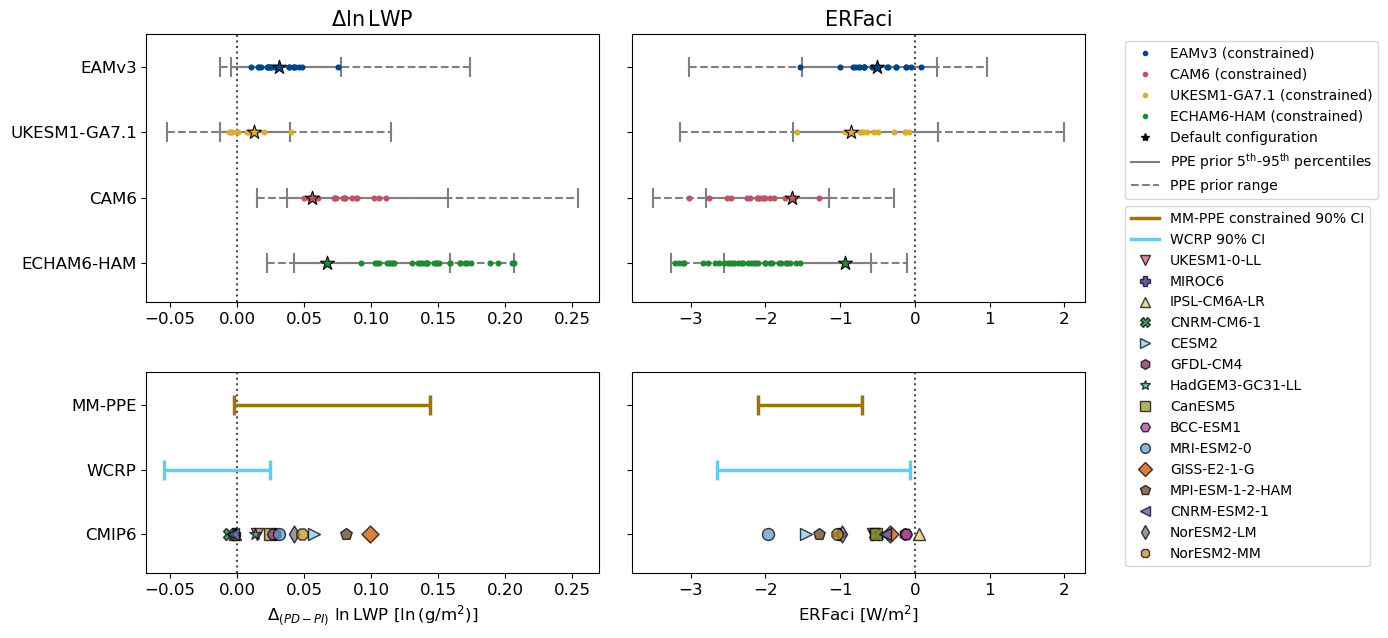

In [45]:
fig = plt.figure(figsize=(14, 7))
gs = GridSpec(2, 3, width_ratios=[1, 1, 0.25], height_ratios=[4, 3])
plt.subplots_adjust(hspace=0.3, wspace=0.1)

# data axes
ax_dlwp1 = plt.subplot(gs[0, 0])
ax_erf1 = plt.subplot(gs[0, 1])
ax_dlwp2 = plt.subplot(gs[1, 0])
ax_erf2 = plt.subplot(gs[1, 1])

# legend axes
ax_leg1 = plt.subplot(gs[0, -1])
ax_leg1.axis("off")
ax_leg2 = plt.subplot(gs[1, -1])
ax_leg2.axis("off")

# same for all
for ax in [ax_erf1, ax_dlwp1, ax_erf2, ax_dlwp2]:
    ax.tick_params(axis="x", labelsize=labsize)
    ax.axvline(0, color="k", linestyle=":", zorder=0, alpha=0.7)#, linewidth=1)

# ytick labels for individual ppes
for ax in [ax_erf1, ax_dlwp1]:
    ax.set_ylim(ylim1)
    ax.set_yticks(yticks1)

# ytick labels for best estimates
for ax in [ax_erf2, ax_dlwp2]:
    ax.set_ylim(ylim2)
    ax.set_yticks(yticks2)
    
ax_dlwp1.set_yticklabels(ytick_labs1, fontsize=fsize)
ax_dlwp2.set_yticklabels(ytick_labs2, fontsize=fsize)
ax_erf1.set_yticklabels([])
ax_erf2.set_yticklabels([])

ax_dlwp2.set_xlabel(r"$\Delta_{(PD-PI)}$ $\ln$LWP [$\ln$(g/m$^2$)]", fontsize=fsize)
ax_erf2.set_xlabel("ERFaci [W/m$^2$]", fontsize=fsize)
ax_dlwp1.set_title(r"$\Delta$$\ln$LWP", fontsize=tsize)
ax_erf1.set_title("ERFaci", fontsize=tsize)


# ==== show individual PPEs - prior range, prior 5th-95th, constrained members, default ====
# -- dlnlwp --
for i, ppe in enumerate(list(ds_dict.keys())):
    y = 3.5 - i
    dlnlwp = ds_dict[ppe]["delta_lnLWP"]
    good_tol = good_ensn_dict[ppe]

    # prior (range)
    dlwp_range_prior = [dlnlwp.min(), dlnlwp.max()]
    pmean = 0.5*np.sum(dlwp_range_prior)
    perr = dlwp_range_prior[1] - pmean
    err = ax_dlwp1.errorbar(y=y, x=pmean, xerr=perr, capsize=capsize, color="grey", zorder=0, elinewidth=error_width-1,
                 capthick=error_width-1)
    err[-1][0].set_linestyle("--")

    # prior (5th-95th)
    dlwp_90range_prior = [dlnlwp.quantile(0.05), dlnlwp.quantile(0.95)]
    pmean = 0.5*np.sum(dlwp_90range_prior)
    perr = dlwp_90range_prior[1] - pmean
    ax_dlwp1.errorbar(y=y, x=pmean, xerr=perr, capsize=capsize, color="grey", zorder=0, elinewidth=error_width-1,
                 capthick=error_width-1)
    
    # posterior - constrained members
    # print(good_tol)
    dlwp_post = dlnlwp.sel(member=good_tol)
    for ensn in dlwp_post.member.values:
        ax_dlwp1.scatter(dlwp_post.sel(member=ensn), y, color=col_dict[ppe], s=s_cmip6*.6, marker=".")

    # mark default
    if ppe == "CAM6":
        df = "000"
    else:
        df = 0
    ax_dlwp1.scatter(dlnlwp.sel(member=df), y=y, color=col_dict[ppe], marker="*", zorder=100, s=s_cmip6*1.5, 
                     edgecolor="k", lw=0.75)

# -- erfaci --
for i, ppe in enumerate(list(ds_dict.keys())):
    y = 3.5 - i
    erfaci = ds_dict[ppe]["ERFaci"]
    good_tol = good_ensn_dict[ppe]

    # prior (range)
    erfaci_range_prior = [erfaci.min(), erfaci.max()]
    pmean = 0.5*np.sum(erfaci_range_prior)
    perr = erfaci_range_prior[1] - pmean
    err = ax_erf1.errorbar(y=y, x=pmean, xerr=perr, capsize=capsize, color="grey", zorder=0, elinewidth=error_width-1,
                 capthick=error_width-1)
    err[-1][0].set_linestyle("--")

    # prior (5th-95th)
    erf_90range_prior = [erfaci.quantile(0.05), erfaci.quantile(0.95)]
    pmean = 0.5*np.sum(erf_90range_prior)
    perr = erf_90range_prior[1] - pmean
    ax_erf1.errorbar(y=y, x=pmean, xerr=perr, capsize=capsize, color="grey", zorder=0, elinewidth=error_width-1,
                 capthick=error_width-1)
    
    # posterior - constrained members
    erfaci_post = erfaci.sel(member=good_tol)
    for ensn in erfaci_post.member.values:
        ax_erf1.scatter(erfaci_post.sel(member=ensn), y, color=col_dict[ppe], s=s_cmip6*.6, marker=".")

    # mark default
    if ppe == "CAM6":
        df = "000"
    else:
        df = 0
    ax_erf1.scatter(erfaci.sel(member=df), y=y, color=col_dict[ppe], marker="*", zorder=100, s=s_cmip6*1.5, 
                     edgecolor="k", lw=0.75)


# ==== show combined & WCRP & CMIP6 ====
# -- dlnlwp --
ax_dlwp2.set_xlim(ax_dlwp1.get_xlim())

# multi-PPE
mpmean = 0.5*np.sum(ci90_dlnlwp)
mperr = ci90_dlnlwp[1] - mpmean
mpe = ax_dlwp2.errorbar(y=2.5, x=mpmean, xerr=mperr, capsize=capsize, color=est_col, elinewidth=error_width,
                 capthick=error_width)

# WCRP
wmean = 0.5*np.sum(wcrp_dlnlwp_range)
werr = wcrp_dlnlwp_range[1] - wmean
ax_dlwp2.errorbar(y=1.5, x=wmean, xerr=werr, capsize=capsize, color=col_wcrp, elinewidth=error_width,
                 capthick=error_width)

# CMIP6
for i, model in enumerate(cmip6_plot_order):
    ax_dlwp2.scatter(cmip6_dict[model]["delta_lnLWP"], 0.5, color=cmip6_colors[i], marker=cmip6_markers[i],
                    edgecolor="k", linewidth=1, s=s_cmip6, label=model, alpha=cmip6_alph)

# -- erfaci --
ax_erf2.set_xlim(ax_erf1.get_xlim())

# multi-PPE
mpmean = 0.5*np.sum(ci90_erfaci)
mperr = ci90_erfaci[1] - mpmean
mpe = ax_erf2.errorbar(y=2.5, x=mpmean, xerr=mperr, capsize=capsize, color=est_col, elinewidth=error_width,
                 capthick=error_width)

# WCRP
wmean = 0.5*np.sum(wcrp_erfaci_range)
werr = wcrp_erfaci_range[1] - wmean
ax_erf2.errorbar(y=1.5, x=wmean, xerr=werr, capsize=capsize, color=col_wcrp, elinewidth=error_width,
                 capthick=error_width)

# CMIP6
for i, model in enumerate(cmip6_plot_order):
    ax_erf2.scatter(cmip6_dict[model]["ERFaci"], 0.5, color=cmip6_colors[i], marker=cmip6_markers[i],
                    edgecolor="k", linewidth=1, s=s_cmip6, label=model, alpha=cmip6_alph)


# ==== proxy artist legends ====
# PPE prior
e3sm_constrained = mlines.Line2D([], [], ls="", color=col_dict["E3SMv3"], marker=".", label="EAMv3 (constrained)")
cam6_constrained = mlines.Line2D([], [], ls="", color=col_dict["CAM6"], marker=".", label="CAM6 (constrained)")
ga71_constrained = mlines.Line2D([], [], ls="", color=col_dict["GA7.1"], marker=".", label="UKESM1-GA7.1 (constrained)")
eham_constrained = mlines.Line2D([], [], ls="", color=col_dict["ECHAM6-HAM"], marker=".", label="ECHAM6-HAM (constrained)")
df = mlines.Line2D([], [], ls="", color="k", marker="*", label="Default configuration")
line_595 = mlines.Line2D([], [], ls="-", linewidth=error_width-1, color="gray", 
                              label=r"PPE prior 5$^{\text{th}}$-95$^{\text{th}}$ percentiles")
line_range = mlines.Line2D([], [], linewidth=error_width-1, color="gray", ls="--", 
                           label="PPE prior range")
handles1 = [e3sm_constrained, cam6_constrained, ga71_constrained, eham_constrained, df, line_595, line_range]

# combined 
multippeline = mlines.Line2D([], [], linewidth=error_width, color=est_col, linestyle="-",
                                   label="MM-PPE constrained 90% CI")
wcrpline = mlines.Line2D([], [], linewidth=error_width, color=col_wcrp, linestyle="-",
                                   label="WCRP 90% CI")
handles2 = [multippeline, wcrpline]

# CMIP6 legend
for i, model in enumerate(cmip6_plot_order):
    handles2.append(mlines.Line2D([], [], linestyle="", marker=cmip6_markers[i], color=cmip6_colors[i],
                                 label=model, markersize=7, alpha=cmip6_alph, markeredgecolor="k",
                                linewidth=2))

# show legends
ax_leg1.legend(handles=handles1, loc="upper left", fontsize=legsize)
ax_leg2.legend(handles=handles2, loc="lower left", fontsize=legsize)


# --- save ---
if save:
    # plt.savefig(save_dir + "Fig2_summary_constrained_ranges.png", dpi=300, bbox_inches="tight")
    plt.savefig(save_dir + "Fig2_summary_constrained_ranges_Ndpipd.png", dpi=300, bbox_inches="tight")


plt.show()


In [46]:
# 5th-95th percentiles on aggregate constrained MM-PPE data
all_dlnlwp = np.empty((0))
all_erfaci = np.empty((0))

for ppe in list(ds_dict.keys()):
    good_tol = good_ensn_dict[ppe]
    all_dlnlwp = np.concatenate([all_dlnlwp, ds_dict[ppe]["delta_lnLWP"].sel(member=good_tol).values])
    all_erfaci = np.concatenate([all_erfaci, ds_dict[ppe]["ERFaci"].sel(member=good_tol).values])
    

In [47]:
np.percentile(all_dlnlwp, 5), np.percentile(all_dlnlwp, 95)


(0.0005526542663574219, 0.1748075957649986)

In [48]:
np.percentile(all_erfaci, 5), np.percentile(all_erfaci, 95)


(-3.016759265339776, -0.12421646411058822)

In [49]:
# 5th-95th percentiles on aggregate UNconstrained MM-PPE data
all_dlnlwp = np.empty((0))
all_erfaci = np.empty((0))

for ppe in list(ds_dict.keys()):
    all_dlnlwp = np.concatenate([all_dlnlwp, ds_dict[ppe]["delta_lnLWP"].values])
    all_erfaci = np.concatenate([all_erfaci, ds_dict[ppe]["ERFaci"].values])


In [50]:
np.percentile(all_dlnlwp, 5), np.percentile(all_dlnlwp, 95)


(-0.004124116872110861, 0.14184175352553852)

In [51]:
np.percentile(all_erfaci, 5), np.percentile(all_erfaci, 95)


(-2.4930525205382237, 0.14484963652743513)

#### Look at overlap... 

In [52]:
def intersect(range1, range2):
    if range2[0] > range1[1]:
        print("NO OVERLAP")
    else:
        imin = max(range1[0], range2[0])
        imax = min(range1[1], range2[1])
        range12 = [imin, imax]
        return range12

SOME overlap in constrained ERFaci; between -1.535 and -1.537 W/m2

In [53]:
ds_good_vals = [ds_dict[ppe].sel(member=good_ensn_dict[ppe]) for ppe in list(ds_dict.keys())]
ds_good_dict = dict(zip(list(ds_dict.keys()), ds_good_vals))


In [54]:
range1 = [ds_good_dict["E3SMv3"]["ERFaci"].min().values, ds_good_dict["E3SMv3"]["ERFaci"].max().values]
range2 = [ds_good_dict["CAM6"]["ERFaci"].min().values, ds_good_dict["CAM6"]["ERFaci"].max().values]
range3 = [ds_good_dict["GA7.1"]["ERFaci"].min().values, ds_good_dict["GA7.1"]["ERFaci"].max().values]
range4 = [ds_good_dict["ECHAM6-HAM"]["ERFaci"].min().values, ds_good_dict["ECHAM6-HAM"]["ERFaci"].max().values]


In [55]:
range12 = intersect(range1, range2)

In [56]:
range123 = intersect(range12, range3)

In [57]:
range1234 = intersect(range123, range4)
print(range1234)

[array(-1.53548746), array(-1.53722488)]


NO overlap in dlnlwp between all four PPEs (constrained)

In [59]:
range1 = [ds_good_dict["E3SMv3"]["delta_lnLWP"].min().values, ds_good_dict["E3SMv3"]["delta_lnLWP"].max().values]
range2 = [ds_good_dict["CAM6"]["delta_lnLWP"].min().values, ds_good_dict["CAM6"]["delta_lnLWP"].max().values]
range3 = [ds_good_dict["GA7.1"]["delta_lnLWP"].min().values, ds_good_dict["GA7.1"]["delta_lnLWP"].max().values]
range4 = [ds_good_dict["ECHAM6-HAM"]["delta_lnLWP"].min().values, ds_good_dict["ECHAM6-HAM"]["delta_lnLWP"].max().values]


In [60]:
range12 = intersect(range1, range2)
print(range12)

[array(0.04959647), array(0.07539487)]


In [61]:
range123 = intersect(range12, range3)
print(range123)

[array(0.04959647), array(0.03989673, dtype=float32)]


In [62]:
range1234 = intersect(range123, range4)
print(range1234)

NO OVERLAP
None
